In [3]:
#LOAD DATA SET

import pandas as pd

train = pd.read_csv(r"C:\Users\Dipak\Desktop\ML_practice\ML_github\ML_Projects\data\train.csv")
test = pd.read_csv(r"C:\Users\Dipak\Desktop\ML_practice\ML_github\ML_Projects\data\test.csv")

In [6]:
#train.info and shape

print(train.shape)  # (1460, 81)
train.info()

'''
The training set has 1,460 rows and 81 columns (79 features + Id + SalePrice) 
Rishabh Nimje
GitHub
.

train.info() shows data types and counts, and highlights missing values—for example, LotFrontage has missing values, while features like Alley have many'''

(1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 1

'\nThe training set has 1,460 rows and 81 columns (79 features + Id + SalePrice) \nRishabh Nimje\nGitHub\n.\n\ntrain.info() shows data types and counts, and highlights missing values—for example, LotFrontage has missing values, while features like Alley have many'

In [8]:
#Summary statistics

train.describe()

#Provides mean, min, max, standard deviation for numerical features.

#Helps detect anomalies, such as unrealistic SalePrice or outlier values.


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


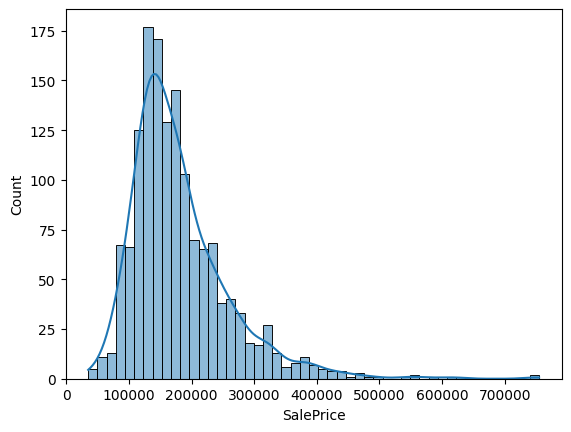

In [9]:
#target distribution
#The SalePrice often shows a right-skewed distribution, hinting that a log transformation may help with modeling 
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(train['SalePrice'], kde=True)
plt.show()


In [10]:
#missing value overview

missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing.head(10))


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
dtype: int64


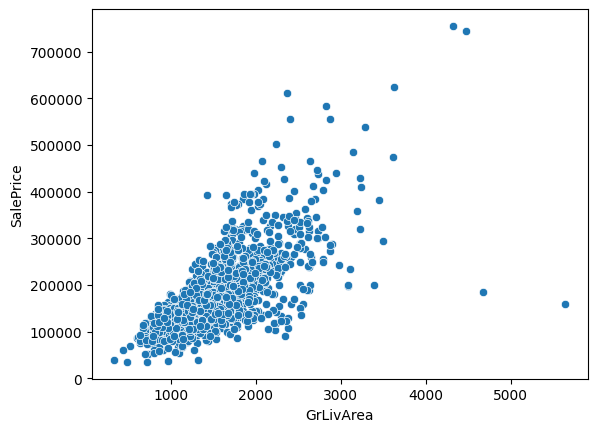

In [11]:
#identify outliers and remove

sns.scatterplot(x=train['GrLivArea'], y=train['SalePrice'])
plt.show()


In [12]:
#Observations with extremely large GrLivArea and low SalePrice can skew training—we may drop such rows (a common practice in public kernels) 

In [13]:
#drop unnecessary columns

train = train.drop(['Id'], axis=1)
test = test.drop(['Id'], axis=1)


In [14]:
# handling missing values

#Categorical features: Missing usually indicates absence
train['Alley'] = train['Alley'].fillna('None')
train['Fence'] = train['Fence'].fillna('None')
train['FireplaceQu'] = train['FireplaceQu'].fillna('None')


In [15]:
#numerical features

train['LotFrontage'] = train['LotFrontage'].fillna(train['LotFrontage'].median())


In [16]:
#For features where missing indicates "none", fill as 0 for numeric (e.g., GarageCars, GarageArea)
#Remove features with >90% missing (e.g., Utilities if it's constant or lacks variance)

In [17]:
#feature creation

#New features like TotalSF (total square footage) and TotalBath (combined bathrooms) often boost model performance 

train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
train['TotalBath'] = train['FullBath'] + 0.5 * train['HalfBath'] + \
                     train['BsmtFullBath'] + 0.5 * train['BsmtHalfBath']


In [20]:
#Encode categorical features

train = pd.get_dummies(train)
test = pd.get_dummies(test)

#Converts categorical variables into one-hot encoded columns.
#Important: align train and test via:

train, test = train.align(test, join='inner', axis=1)




In [21]:
#log-transform the target

import numpy as np
train["SalePrice"] = np.log1p(train["SalePrice"])

#Helps normalize skew, improving regression performance

KeyError: 'SalePrice'

In [22]:
train['SalePrice']

KeyError: 'SalePrice'

In [23]:
train

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,False,False,False,True,False,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,False,False,False,True,False,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,False,False,False,True,False,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,False,False,False,True,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,False,False,False,True,False,False,False,False,True,False
1456,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,False,False,False,True,False,False,False,False,True,False
1457,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,False,False,False,True,False,False,False,False,True,False
1458,20,68.0,9717,5,6,1950,1996,0.0,49,1029,...,False,False,False,True,False,False,False,False,True,False


In [25]:
list(train.columns)

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'MSZoning_C (all)',
 'MSZoning_FV',
 'MSZoning_RH',
 'MSZoning_RL',
 'MSZoning_RM',
 'Street_Grvl',
 'Street_Pave',
 'Alley_Grvl',
 'Alley_Pave',
 'LotShape_IR1',
 'LotShape_IR2',
 'LotShape_IR3',
 'LotShape_Reg',
 'LandContour_Bnk',
 'LandContour_HLS',
 'LandContour_Low',
 'LandContour_Lvl',
 'Utilities_AllPub',
 'LotConfig_Corner',
 'LotConfig_CulDSac',
 'LotConfig_FR2',
 'LotConfig_FR3',
 'LotConfig_Inside',
 'LandSlope_Gtl',
 'LandSlope_Mod',
 'LandSlope_


=== Initial Shapes ===
Train shape: (1460, 81)
Test shape: (1459, 80)

=== Train Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  House

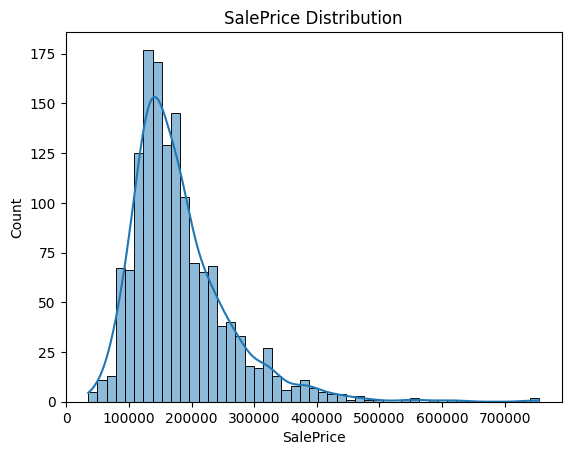

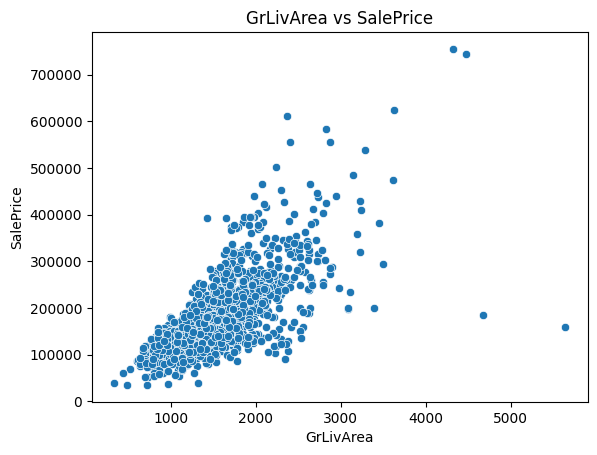


=== After Preprocessing ===
Train features shape: (1168, 286)
Validation features shape: (292, 286)
Test features shape: (1459, 286)

Sample of processed features:
      MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
254           20         70.0     8400            5            6       1957   
1066          60         59.0     7837            6            7       1993   
638           30         67.0     8777            5            7       1910   
799           50         60.0     7200            5            7       1937   
380           50         50.0     5000            5            6       1924   

      YearRemodAdd  MasVnrArea  BsmtFinSF1  BsmtFinSF2  ...  SaleType_ConLw  \
254           1957         0.0         922           0  ...           False   
1066          1994         0.0           0           0  ...           False   
638           1950         0.0           0           0  ...           False   
799           1950       252.0         569  

In [26]:
# house_price_preprocessing.py

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# =============================
# 1. Load datasets
# =============================
train = pd.read_csv(r"C:\Users\Dipak\Desktop\ML_practice\ML_github\ML_Projects\data\train.csv")
test = pd.read_csv(r"C:\Users\Dipak\Desktop\ML_practice\ML_github\ML_Projects\data\test.csv")

print("\n=== Initial Shapes ===")
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

# =============================
# 2. EDA (Exploratory Data Analysis)
# =============================
print("\n=== Train Info ===")
print(train.info())

print("\n=== Missing Values (Top 10) ===")
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing.head(10))

# Plot target distribution
sns.histplot(train["SalePrice"], kde=True)
plt.title("SalePrice Distribution")
plt.show()

# Outlier check example
sns.scatterplot(x=train["GrLivArea"], y=train["SalePrice"])
plt.title("GrLivArea vs SalePrice")
plt.show()

# =============================
# 3. Preprocessing
# =============================

# Drop Id column
train.drop("Id", axis=1, inplace=True)
test.drop("Id", axis=1, inplace=True)

# Log-transform target BEFORE encoding
train["SalePrice"] = np.log1p(train["SalePrice"])

# Save target separately
y = train["SalePrice"]
X = train.drop("SalePrice", axis=1)

# Fill missing values - Categorical -> "None"
cat_cols = X.select_dtypes(include=["object"]).columns
for col in cat_cols:
    X[col] = X[col].fillna("None")
    if col in test.columns:
        test[col] = test[col].fillna("None")

# Fill missing values - Numerical -> median
num_cols = X.select_dtypes(exclude=["object"]).columns
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())
    if col in test.columns:
        test[col] = test[col].fillna(test[col].median())

# Feature engineering
X["TotalSF"] = X["TotalBsmtSF"] + X["1stFlrSF"] + X["2ndFlrSF"]
test["TotalSF"] = test["TotalBsmtSF"] + test["1stFlrSF"] + test["2ndFlrSF"]

X["TotalBath"] = X["FullBath"] + 0.5 * X["HalfBath"] + X["BsmtFullBath"] + 0.5 * X["BsmtHalfBath"]
test["TotalBath"] = test["FullBath"] + 0.5 * test["HalfBath"] + test["BsmtFullBath"] + 0.5 * test["BsmtHalfBath"]

# One-hot encoding
X = pd.get_dummies(X)
test = pd.get_dummies(test)

# Align columns
X, test = X.align(test, join="inner", axis=1)

# =============================
# 4. Train/Test Split
# =============================
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =============================
# 5. Output shapes and confirmation
# =============================
print("\n=== After Preprocessing ===")
print(f"Train features shape: {X_train.shape}")
print(f"Validation features shape: {X_valid.shape}")
print(f"Test features shape: {test.shape}")

print("\nSample of processed features:")
print(X_train.head())
